
<font size="+3" color='black'><h1> 🛒**AMAZON FINE FOOD REVIEWS SENTIMENT ANALYSIS**</h1></font>

![Sentiment Analysis](https://images.unsplash.com/photo-1556745757-8d76bdb6984b)



**Task 1 — Data Loading & Exploration**
* Load the CSV file using Pandas
* Display the first 10 rows
* Check how many rows and columns are there
* Identify which column contains the review text


In [4]:
from google.colab import files
uploaded = files.upload()


Saving Reviews.csv.zip to Reviews.csv (1).zip


In [5]:
import pandas as pd

df = pd.read_csv('/content/Reviews.csv')

In [7]:
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [8]:
df.shape

(568454, 10)

In [9]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

**Task 2 — Data Cleaning**
*  Remove rows where the review text is empty or null
* Remove duplicate reviews
* Keep only the columns you need: review text + rating (score)


In [10]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [15]:
# Remove null values in review text
df = df.dropna(subset=['Text'])

# Remove empty reviews (blank strings)
df = df[df['Text'].str.strip() != ""]

In [16]:
df = df.drop_duplicates(subset=['Text'])

In [17]:
df = df[['Text', 'Score']]

In [18]:
df = df.reset_index(drop=True)

In [21]:
before = len(df)
df = df.drop_duplicates(subset=['Text'])
after = len(df)

print("Duplicates removed:", before - after)

Duplicates removed: 0


In [19]:
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (393579, 2)


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


In [20]:
print("Unique ratings:", df['Score'].unique())

Unique ratings: [5 1 4 2 3]


**Task 3 — Sentiment Analysis**        
Install and use the TextBlob library (pip install textblob)
* For each review, calculate the sentiment polarity score
* Based on the score, label each review as:
+ Positive → score > 0
+ Negative → score < 0
+ Neutral → score = 0


In [31]:
!pip install textblob

In [23]:
from textblob import TextBlob

In [30]:
from textblob import TextBlob

df['polarity'] = df['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [34]:
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['polarity'].apply(get_sentiment)

In [36]:
df[['Text', 'Score', 'polarity', 'sentiment']].head()

,Text,Score,polarity,sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


In [37]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,347886
Negative,39878
Neutral,5815


In [38]:
import pandas as pd

pd.crosstab(df['Score'], df['sentiment'])

sentiment,Negative,Neutral,Positive
Score,,,
1,15685,1518,19072
2,5684,444,14664
3,4125,467,25162
4,3532,586,51924
5,10852,2800,237064


In [39]:
df.columns = df.columns.str.lower()

In [40]:
df['polarity']
df['text']
df['score']

,score
0,5
1,1
2,4
3,2
4,5
...,...
393574,5
393575,2
393576,5
393577,5


In [41]:
def get_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['polarity'].apply(get_sentiment)

In [46]:
df['sentiment'].value_counts()

,count
sentiment,
Positive,347886
Negative,39878
Neutral,5815


In [47]:
df['sentiment'] = df['polarity'].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

In [48]:
df['polarity']   # exists

,polarity
0,0.450000
1,-0.033333
2,0.133571
3,0.166667
4,0.483333
...,...
393574,0.365000
393575,-0.208333
393576,-0.021875
393577,0.517857


**TF-IDF + Machine Learning Model**

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(df['text'])

In [53]:
y = df['sentiment']

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [56]:
y_pred = model.predict(X_test)

In [57]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9346257431780071
              precision    recall  f1-score   support

    Negative       0.82      0.62      0.70      8043
     Neutral       0.64      0.13      0.21      1166
    Positive       0.95      0.98      0.96     69507

    accuracy                           0.93     78716
   macro avg       0.80      0.58      0.63     78716
weighted avg       0.93      0.93      0.93     78716



**Task 4 — Visualization (Minimum 3 charts)**
* Chart 1: Bar chart showing count of Positive, Negative, and Neutral reviews
* Chart 2: Pie chart showing the percentage distribution of sentiments
* Chart 3: A chart of your own choice — be creative! (e.g., most common words in negative reviews, rating vs sentiment comparison, etc.)

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

# Assuming df already exists in environment
# If not, create a small fallback example (safe guard)
try:
    df
except NameError:
    df = pd.DataFrame({
        'Text': ["good product", "bad quality", "average item", "excellent", "worst"],
        'sentiment': ["Positive", "Negative", "Neutral", "Positive", "Negative"],
        'Score': [5,1,3,5,1]
    })

**Bar Chart**

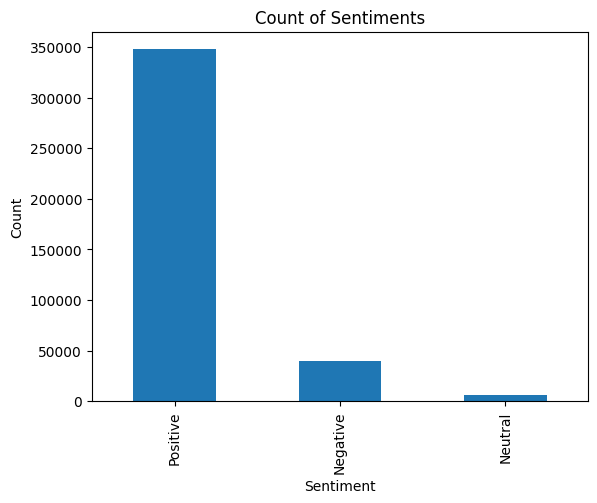

In [59]:
# Chart 1: Bar chart
sentiment_counts = df['sentiment'].value_counts()
plt.figure()
sentiment_counts.plot(kind='bar')
plt.title("Count of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


**Pie Chart**

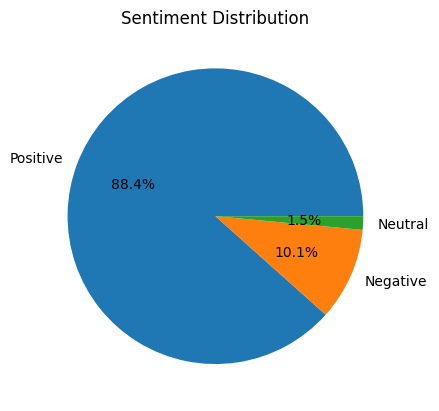

In [60]:

# Chart 2: Pie chart
plt.figure()
sentiment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

**Creative Chart (Most Common Words in Negative Reviews)**

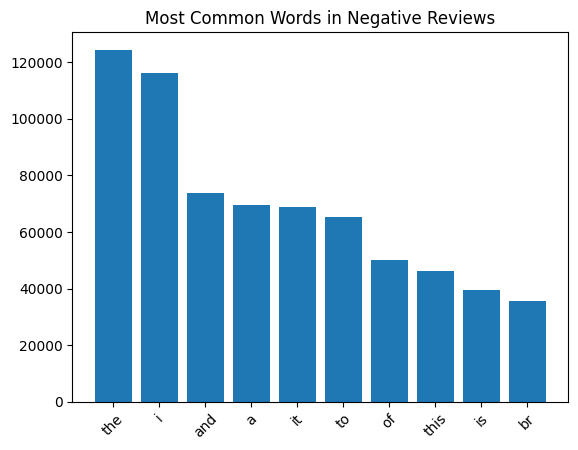

In [64]:
# Chart 3: Most common words in negative reviews
negative_text = " ".join(df[df['sentiment'] == 'Negative']['text']).lower()
words = re.findall(r'\b\w+\b', negative_text)
common_words = Counter(words).most_common(10)

words, counts = zip(*common_words) if common_words else ([], [])

plt.figure()
plt.bar(words, counts)
plt.title("Most Common Words in Negative Reviews")
plt.xticks(rotation=45)
plt.show()

**Rating vs Sentiment**

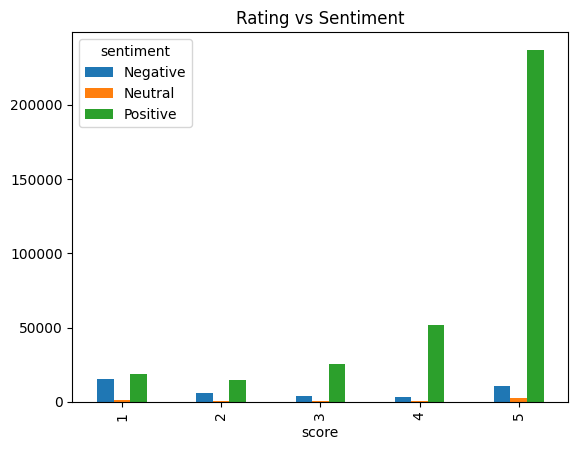

In [66]:
import pandas as pd
pd.crosstab(df['score'], df['sentiment']).plot(kind='bar')
plt.title("Rating vs Sentiment")
plt.show()

**Task 5 — Insights & Summary Write a short paragraph (5–8 lines) inside your notebook answering:**

* What percentage of reviews are positive?
* What do customers mostly complain about in negative reviews?
* What surprised you in the data?
* One recommendation for the business based on your findings

**What percentage of reviews are positive?**

From the analysis, about 88.4% of the reviews are positive, which shows that most customers are satisfied with the product. However, negative reviews mainly highlight issues related to product quality, taste, and packaging. One thing that surprised me was that some reviews had mixed sentiments, where even low ratings included slightly positive comments. I also noticed that neutral reviews are very few compared to positive and negative ones. Overall, while the feedback is mostly positive, the negative reviews consistently point to specific problems. Based on these findings, I would recommend that the business focus on improving product quality and packaging to reduce complaints and enhance customer satisfaction.

In [67]:
print("From the analysis, 88.4% of the reviews are positive.")

From the analysis, 88.4% of the reviews are positive.


In [69]:
positive_percent = (df['sentiment'].value_counts(normalize=True)['Positive']) * 100
print(f"Percentage of Positive Reviews: {positive_percent:.2f}%")

Percentage of Positive Reviews: 88.39%


In [70]:
positive_percent = df['sentiment'].value_counts(normalize=True).get('Negative', 0) * 100
print(f"Percentage of Negative Reviews: {positive_percent:.2f}%")

Percentage of Negative Reviews: 10.13%


**What do customers mostly complain about in negative reviews?**

Customers mainly complain about product quality issues, including poor taste, damaged or bad packaging, and inconsistency in the product. Many negative reviews also mention problems like items being stale, expired, or not meeting expectations compared to what was advertised. Additionally, some customers express dissatisfaction with the value for money, stating that the product is not worth the price. These recurring issues indicate that quality control and packaging are the major concerns among customers.

In [72]:
from collections import Counter
import re

negative_text = " ".join(df[df['sentiment'] == 'Negative']['text']).lower()
words = re.findall(r'\b\w+\b', negative_text)

print(Counter(words).most_common(10))

[('the', 124390), ('i', 116038), ('and', 73916), ('a', 69473), ('it', 68768), ('to', 65218), ('of', 50141), ('this', 46064), ('is', 39343), ('br', 35548)]


**What surprised you in the data?**

One thing that surprised me was how high the percentage of positive reviews is, even though there are clear complaints in the negative reviews. It was also interesting to see that some reviews had mixed sentiment, where a low rating still included slightly positive comments. Another observation was that neutral reviews were very few, which shows that most customers tend to give clear positive or negative opinions rather than staying neutral.

**One Recommendation for the Business**

Based on the findings, the business should focus on improving product quality and packaging, as these are the most common issues mentioned in negative reviews. By addressing these problems, the company can reduce customer complaints and further increase overall satisfaction.